# **Employee Burnout Prediction Using Explainable Machine Learning Models**

In [1]:
import warnings

# Suppress known FutureWarnings from SHAP/NumPy
warnings.filterwarnings(
    "ignore",
    message=".*NumPy global RNG was seeded.*",
    category=FutureWarning
)

# importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import LabelEncoder
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_score
)
from xgboost import XGBClassifier
import joblib
import shap
import random
random.seed(42)
np.random.seed(42)

In [2]:
# load dataset
df = pd.read_csv("employee_dataset.csv")

In [3]:
# to preview the first 5 rows
display(df.head())

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Years in Company,Work Hours per Week,Sleep Hours,Work-Life Balance Score,Manager Support Score,Deadline Pressure Score,Team Size,Recognition Frequency
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2,3.0,3.8,0.16,16,35,7.5,3,3,1,16,2
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1,2.0,5.0,0.36,16,41,7.1,5,3,3,10,5
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2,NaN,5.8,0.49,16,53,5.7,2,3,5,17,0
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1,1.0,2.6,0.20,16,43,6.7,3,3,1,13,2
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3,7.0,6.9,0.52,16,51,5.2,1,3,4,18,0


In [4]:
# preview datset information
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee ID              22750 non-null  object 
 1   Date of Joining          22750 non-null  object 
 2   Gender                   22750 non-null  object 
 3   Company Type             22750 non-null  object 
 4   WFH Setup Available      22750 non-null  object 
 5   Designation              22750 non-null  int64  
 6   Resource Allocation      21369 non-null  float64
 7   Mental Fatigue Score     20633 non-null  float64
 8   Burn Rate                21626 non-null  float64
 9   Years in Company         22750 non-null  int64  
 10  Work Hours per Week      22750 non-null  int64  
 11  Sleep Hours              22750 non-null  float64
 12  Work-Life Balance Score  22750 non-null  int64  
 13  Manager Support Score    22750 non-null  int64  
 14  Deadline Pressure Scor

None

In [5]:
# Check for duplicate records
duplicates = df.duplicated().sum()

print(f"Duplicate records: {duplicates}")

Duplicate records: 0


In [6]:
# check afor missing values
df.isnull().sum()


Employee ID                   0
Date of Joining               0
Gender                        0
Company Type                  0
WFH Setup Available           0
Designation                   0
Resource Allocation        1381
Mental Fatigue Score       2117
Burn Rate                  1124
Years in Company              0
Work Hours per Week           0
Sleep Hours                   0
Work-Life Balance Score       0
Manager Support Score         0
Deadline Pressure Score       0
Team Size                     0
Recognition Frequency         0
dtype: int64

In [7]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

### **Data Cleaning**

In [8]:
df["Employee ID"] = df["Employee ID"].astype("string")
df["Date of Joining"] = df["Date of Joining"].astype("datetime64[ns]")
df["Gender"] = df["Gender"].astype("category")
df["Company Type"] = df["Company Type"].astype("category")
df["WFH Setup Available"] = df["WFH Setup Available"].astype("category")
df["Designation"] = pd.Categorical(df["Designation"], categories=[0, 1, 2, 3, 4, 5], ordered=True)
df["Recognition Frequency"] = pd.Categorical(df["Recognition Frequency"], categories=[0, 1, 2, 3, 4, 5], ordered=True)


In [9]:
# drop unnecessary columns
df.drop(columns=["Employee ID", "Date of Joining"], inplace=True)

In [10]:
# Remove rows where the target (Burn Rate) value is missing
df = df.dropna(subset=["Burn Rate"])
df = df.reset_index(drop=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21626 entries, 0 to 21625
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Gender                   21626 non-null  category
 1   Company Type             21626 non-null  category
 2   WFH Setup Available      21626 non-null  category
 3   Designation              21626 non-null  category
 4   Resource Allocation      20348 non-null  float64 
 5   Mental Fatigue Score     19681 non-null  float64 
 6   Burn Rate                21626 non-null  float64 
 7   Years in Company         21626 non-null  int64   
 8   Work Hours per Week      21626 non-null  int64   
 9   Sleep Hours              21626 non-null  float64 
 10  Work-Life Balance Score  21626 non-null  int64   
 11  Manager Support Score    21626 non-null  int64   
 12  Deadline Pressure Score  21626 non-null  int64   
 13  Team Size                21626 non-null  int64   
 14  Recogn

In [12]:
# Encoding the categorical variables

# Encode Gender
df["Gender"] = df["Gender"].map({
    "Female": 0,
    "Male": 1
})

# Encode Company Type
df["Company Type"] = df["Company Type"].map({
    "Service": 0,
    "Product": 1
})

# Encode WFH Setup Available
df["WFH Setup Available"] = df["WFH Setup Available"].map({
    "No": 0,
    "Yes": 1
})

In [13]:
# convert the categorical variables to integers
df["Gender"] = df["Gender"].astype("int8")
df["Company Type"] = df["Company Type"].astype("int8")
df["WFH Setup Available"] = df["WFH Setup Available"].astype("int8")
df["Designation"] = df["Designation"].astype("int8")
df["Recognition Frequency"] = df["Recognition Frequency"].astype("int8")

In [14]:
# check data information after encoding and 
# conversion of categorical variables to integers
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21626 entries, 0 to 21625
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   21626 non-null  int8   
 1   Company Type             21626 non-null  int8   
 2   WFH Setup Available      21626 non-null  int8   
 3   Designation              21626 non-null  int8   
 4   Resource Allocation      20348 non-null  float64
 5   Mental Fatigue Score     19681 non-null  float64
 6   Burn Rate                21626 non-null  float64
 7   Years in Company         21626 non-null  int64  
 8   Work Hours per Week      21626 non-null  int64  
 9   Sleep Hours              21626 non-null  float64
 10  Work-Life Balance Score  21626 non-null  int64  
 11  Manager Support Score    21626 non-null  int64  
 12  Deadline Pressure Score  21626 non-null  int64  
 13  Team Size                21626 non-null  int64  
 14  Recognition Frequency 

In [15]:
# Check for duplicate rows after cleaning and encoding
df.duplicated().sum()

np.int64(0)

In [16]:
# Examine the distribution of the target variable (Burn Rate)
df["Burn Rate"].describe()

count    21626.000000
mean         0.452005
std          0.198226
min          0.000000
25%          0.310000
50%          0.450000
75%          0.590000
max          1.000000
Name: Burn Rate, dtype: float64

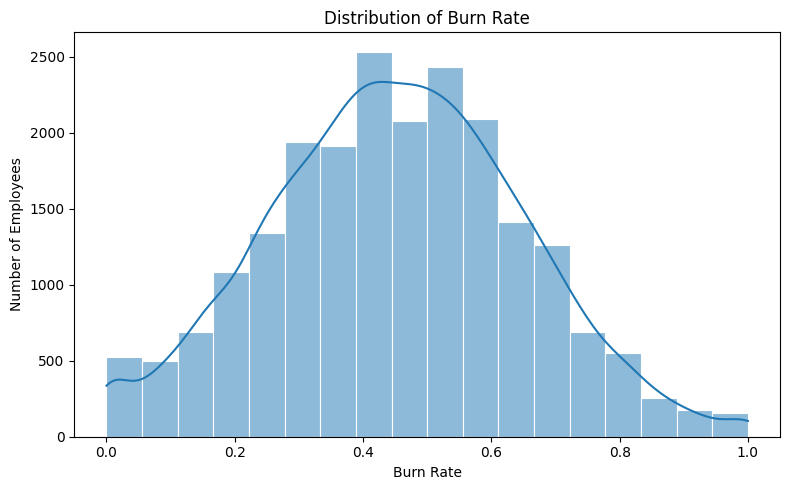

In [17]:
# Burnrate distribution plot
# Distribution of Burn Rate
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Burn Rate"],
    bins=18,
    kde=True,
    stat="count",
    edgecolor="white",
    linewidth=0.8
)

plt.xlabel("Burn Rate")
plt.ylabel("Number of Employees")
plt.title("Distribution of Burn Rate")

plt.tight_layout()
plt.show()

### **Correlation Analysis**

In [18]:
corr = df.corr(numeric_only=True)
corr["Burn Rate"].sort_values(ascending=False)

Burn Rate                  1.000000
Mental Fatigue Score       0.944546
Resource Allocation        0.856278
Designation                0.737556
Work Hours per Week        0.719672
Deadline Pressure Score    0.707959
Gender                     0.154895
Team Size                  0.002194
Years in Company           0.000929
Company Type              -0.004281
WFH Setup Available       -0.306266
Manager Support Score     -0.608987
Sleep Hours               -0.655305
Recognition Frequency     -0.696428
Work-Life Balance Score   -0.708113
Name: Burn Rate, dtype: float64

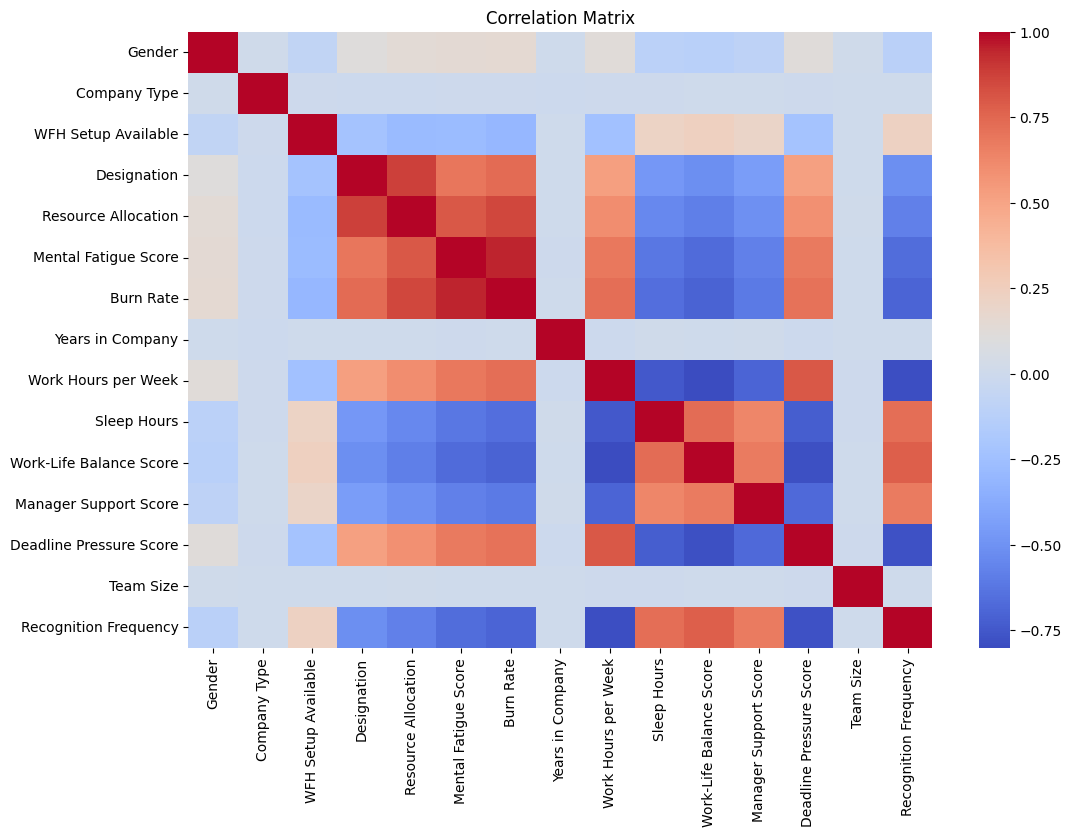

In [19]:


plt.figure(figsize=(12,8))
sns.heatmap(corr,
            cmap="coolwarm",
            annot=False)

plt.title("Correlation Matrix")
plt.show()

### **Check for Outliers**

In [20]:
# Define the variables suitable for outlier analysis
outlier_cols = [
    "Resource Allocation",
    "Mental Fatigue Score",
    "Years in Company",
    "Work Hours per Week",
    "Sleep Hours",
    "Work-Life Balance Score",
    "Manager Support Score",
    "Deadline Pressure Score",
    "Team Size",
    "Recognition Frequency"
]

# Count outliers using the IQR rule
outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        "Variable": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Limit": round(lower, 2),
        "Upper Limit": round(upper, 2),
        "No. of Outliers": len(outliers)
    })

# Display summary
outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Variable,Q1,Q3,IQR,Lower Limit,Upper Limit,No. of Outliers
0,Resource Allocation,3.0,6.0,3.0,-1.50,10.50,0
1,Mental Fatigue Score,4.6,7.1,2.5,0.85,10.85,326
2,Years in Company,16.0,16.0,0.0,16.00,16.00,352
3,Work Hours per Week,41.0,54.0,13.0,21.50,73.50,0
4,Sleep Hours,5.4,6.9,1.5,3.15,9.15,0
5,Work-Life Balance Score,1.0,4.0,3.0,-3.50,8.50,0
6,Manager Support Score,2.0,4.0,2.0,-1.00,7.00,0
7,Deadline Pressure Score,2.0,5.0,3.0,-2.50,9.50,0
8,Team Size,7.0,15.0,8.0,-5.00,27.00,0
9,Recognition Frequency,0.0,3.0,3.0,-4.50,7.50,0


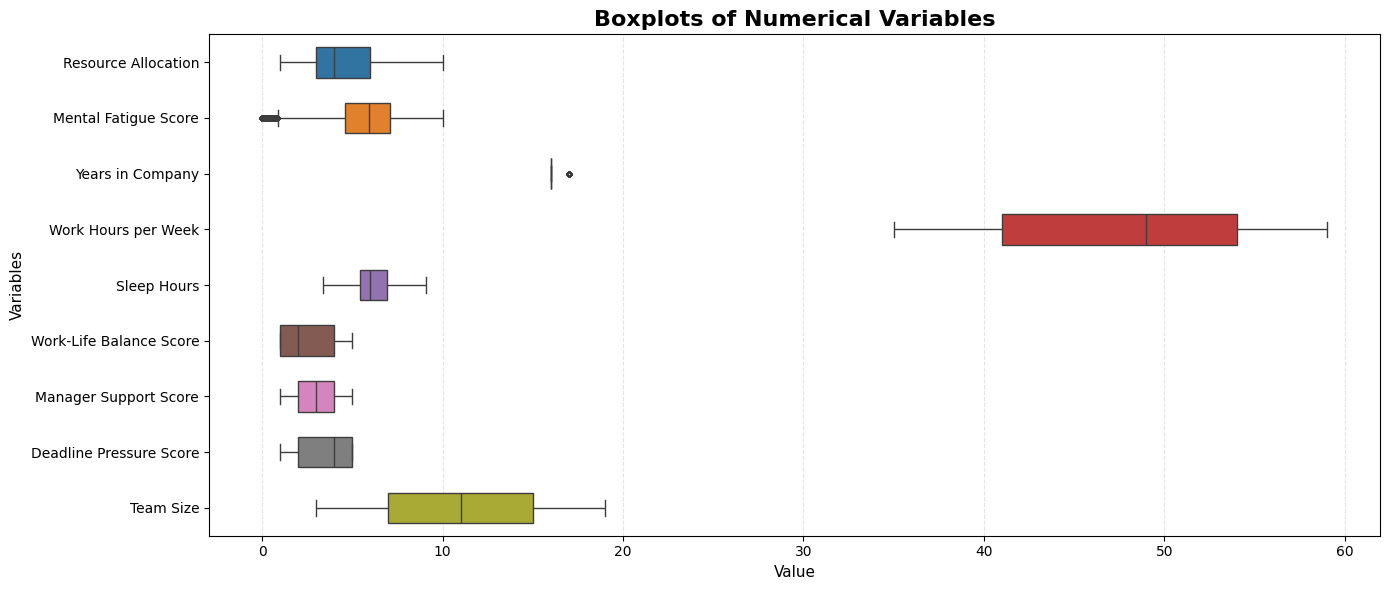

In [21]:

# Combined Boxplot for Outlier Assessment

# Continuous numerical variables only
boxplot_cols = [
    "Resource Allocation",
    "Mental Fatigue Score",
    "Years in Company",
    "Work Hours per Week",
    "Sleep Hours",
    "Work-Life Balance Score",
    "Manager Support Score",
    "Deadline Pressure Score",
    "Team Size"
]

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df[boxplot_cols],
    orient="h",
    linewidth=1,
    fliersize=3,
    width=0.55          # slightly thinner boxes
)

plt.title(
    "Boxplots of Numerical Variables",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Value", fontsize=11)
plt.ylabel("Variables", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [22]:
# Display the actual outlier values for each variable
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print(f"Number of outliers: {len(outliers)}")

    if len(outliers) > 0:
        print(outliers[[col]])


Resource Allocation
Number of outliers: 0

Mental Fatigue Score
Number of outliers: 326
       Mental Fatigue Score
79                      0.8
93                      0.0
193                     0.0
218                     0.0
235                     0.5
...                     ...
21291                   0.6
21346                   0.8
21363                   0.0
21398                   0.2
21433                   0.5

[326 rows x 1 columns]

Years in Company
Number of outliers: 352
       Years in Company
6                    17
92                   17
113                  17
200                  17
470                  17
...                 ...
21389                17
21437                17
21517                17
21521                17
21625                17

[352 rows x 1 columns]

Work Hours per Week
Number of outliers: 0

Sleep Hours
Number of outliers: 0

Work-Life Balance Score
Number of outliers: 0

Manager Support Score
Number of outliers: 0

Deadline Pressure Score
Nu

In [23]:
df["Mental Fatigue Score"].describe()

count    19681.000000
mean         5.729851
std          1.920784
min          0.000000
25%          4.600000
50%          5.900000
75%          7.100000
max         10.000000
Name: Mental Fatigue Score, dtype: float64

In [24]:
df["Mental Fatigue Score"].skew()

np.float64(-0.4326392073866463)

In [25]:
# Final Dataset verification

print(df.shape)
df.info()
df.describe()

(21626, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21626 entries, 0 to 21625
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   21626 non-null  int8   
 1   Company Type             21626 non-null  int8   
 2   WFH Setup Available      21626 non-null  int8   
 3   Designation              21626 non-null  int8   
 4   Resource Allocation      20348 non-null  float64
 5   Mental Fatigue Score     19681 non-null  float64
 6   Burn Rate                21626 non-null  float64
 7   Years in Company         21626 non-null  int64  
 8   Work Hours per Week      21626 non-null  int64  
 9   Sleep Hours              21626 non-null  float64
 10  Work-Life Balance Score  21626 non-null  int64  
 11  Manager Support Score    21626 non-null  int64  
 12  Deadline Pressure Score  21626 non-null  int64  
 13  Team Size                21626 non-null  int64  
 14  Recognitio

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Years in Company,Work Hours per Week,Sleep Hours,Work-Life Balance Score,Manager Support Score,Deadline Pressure Score,Team Size,Recognition Frequency
count,21626.000000,21626.000000,21626.000000,21626.000000,20348.000000,19681.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000
mean,0.475215,0.346897,0.540322,2.178766,4.483831,5.729851,0.452005,16.016277,47.774253,6.111001,2.523583,2.816147,3.473920,11.064459,1.732082
std,0.499397,0.475994,0.498383,1.135428,2.048170,1.920784,0.198226,0.126541,7.601375,0.887864,1.389781,1.273673,1.394685,4.909465,1.693670
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,16.000000,35.000000,3.400000,1.000000,1.000000,1.000000,3.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,3.000000,4.600000,0.310000,16.000000,41.000000,5.400000,1.000000,2.000000,2.000000,7.000000,0.000000
50%,0.000000,0.000000,1.000000,2.000000,4.000000,5.900000,0.450000,16.000000,49.000000,6.000000,2.000000,3.000000,4.000000,11.000000,1.000000
75%,1.000000,1.000000,1.000000,3.000000,6.000000,7.100000,0.590000,16.000000,54.000000,6.900000,4.000000,4.000000,5.000000,15.000000,3.000000
max,1.000000,1.000000,1.000000,5.000000,10.000000,10.000000,1.000000,17.000000,59.000000,9.100000,5.000000,5.000000,5.000000,19.000000,5.000000


In [26]:
# Select only numerical predictor variables
# Select only numerical predictor variables
X_vif = df.select_dtypes(include=["int64", "float64"]).drop(columns=["Burn Rate"]).copy()

# Temporary median imputation for VIF calculation only
X_vif = X_vif.fillna(X_vif.median())

# Add intercept
X_vif = add_constant(X_vif)

# Calculate VIF
vif = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Round VIF values
vif["VIF"] = vif["VIF"].round(2)

# Remove intercept
vif = vif[vif["Feature"] != "const"]

print(vif)


                   Feature   VIF
1      Resource Allocation  2.32
2     Mental Fatigue Score  2.79
3         Years in Company  1.00
4      Work Hours per Week  4.14
5              Sleep Hours  2.73
6  Work-Life Balance Score  3.65
7    Manager Support Score  2.24
8  Deadline Pressure Score  3.68
9                Team Size  1.00


In [27]:
df["Burn Rate"].describe()

count    21626.000000
mean         0.452005
std          0.198226
min          0.000000
25%          0.310000
50%          0.450000
75%          0.590000
max          1.000000
Name: Burn Rate, dtype: float64

In [28]:
df["Burn Rate"].quantile([0.33, 0.67])

0.33    0.36
0.67    0.54
Name: Burn Rate, dtype: float64

In [29]:
# Calculate percentile thresholds
low_threshold = df["Burn Rate"].quantile(0.33)
high_threshold = df["Burn Rate"].quantile(0.67)

# Create burnout categories
df["Burnout_Level"] = pd.cut(
    df["Burn Rate"],
    bins=[-float("inf"), low_threshold, high_threshold, float("inf")],
    labels=["Low", "Moderate", "High"],
    include_lowest=True
)

df["Burnout_Level"].value_counts()

Burnout_Level
Moderate    7459
Low         7191
High        6976
Name: count, dtype: int64

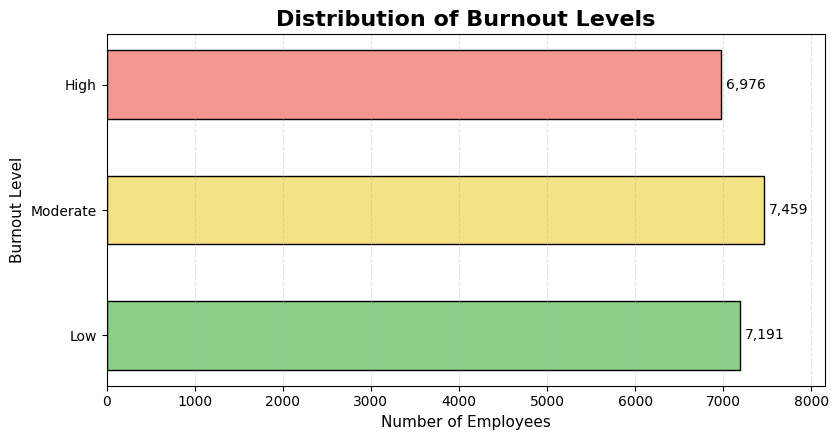

In [30]:
# Count burnout levels
burnout_counts = (
    df["Burnout_Level"]
    .value_counts()
    .reindex(["Low", "Moderate", "High"])
)

# Plot
plt.figure(figsize=(8.5, 4.5))

bars = plt.barh(
    burnout_counts.index,
    burnout_counts.values,
    height=0.55,                     # <-- Thinner bars
    color=["#8BCF88", "#F4E285", "#F4978E"],
    edgecolor="black",
    linewidth=1.0
)

# Add labels with more spacing
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 60,                  # <-- More space from the bar
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center",
        ha="left",
        fontsize=10
    )

# Add space to the right for labels
plt.xlim(0, burnout_counts.max() + 700)

plt.title(
    "Distribution of Burnout Levels",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Employees", fontsize=11)
plt.ylabel("Burnout Level", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [31]:
# Inspect to preview the burnout levels
df[["Burn Rate", "Burnout_Level"]].head(10)

,Burn Rate,Burnout_Level
0,0.16,Low
1,0.36,Low
2,0.49,Moderate
3,0.20,Low
4,0.52,Moderate
5,0.29,Low
6,0.62,High
7,0.33,Low
8,0.56,High
9,0.67,High


In [32]:
# Save the transformed dataset
df.to_csv("employee_burnout_processed.csv", index=False)

# **Modelling**

In [33]:
# Features
X = df.drop(columns=["Burn Rate", "Burnout_Level"])

# Target
y = df["Burnout_Level"]

In [34]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape
X_test.shape

(4326, 14)

In [35]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (17300, 14)
Testing Features : (4326, 14)
Training Target  : (17300,)
Testing Target   : (4326,)


In [36]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

2569
654


In [37]:
# Median imputation for missing values in 'Resource Allocation' and 'Mental Fatigue Score' columns

# Compute medians from the training data
resource_median = X_train["Resource Allocation"].median()
fatigue_median = X_train["Mental Fatigue Score"].median()

# Apply the medians to the training set
X_train["Resource Allocation"] = X_train["Resource Allocation"].fillna(resource_median)
X_train["Mental Fatigue Score"] = X_train["Mental Fatigue Score"].fillna(fatigue_median)

# Apply the same medians to the test set
X_test["Resource Allocation"] = X_test["Resource Allocation"].fillna(resource_median)
X_test["Mental Fatigue Score"] = X_test["Mental Fatigue Score"].fillna(fatigue_median)

In [38]:
# Encode the target
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print(label_encoder.classes_)

['High' 'Low' 'Moderate']


### **Hyperparameter Tunning**

In [39]:
# Parameter Grid

param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [3, 4, 5, 6, 8],

    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    "min_child_weight": [1, 3, 5]
}

# Base Model

xgb = XGBClassifier(
    objective="multi:softmax",
    random_state=42,
    eval_metric="mlogloss"
)

# Randomised Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search.fit(X_train, y_train)

# Best Parameters
print("Best Parameters")
print(random_search.best_params_)

Best Parameters
{'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [40]:
# Final Hypertuned Model
best_xgb = random_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

In [41]:
# Build EBM Model
ebm = ExplainableBoostingClassifier(
    interactions=0,
    random_state=42
)

ebm.fit(X_train, y_train)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,0
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


In [42]:
# Create a 5-fold stratified cross-validator
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Perform cross-validation
cv_acc_ebm = cross_val_score(
    ebm,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

cv_f1_ebm = cross_val_score(
    ebm,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

print(f"Mean Accuracy: {cv_acc_ebm.mean():.4f}")
print(f"Mean Weighted F1: {cv_f1_ebm.mean():.4f}")

Mean Accuracy: 0.8458
Mean Weighted F1: 0.8427


In [43]:
# Train EBM
ebm.fit(X_train, y_train)

# Predict on the test set
y_pred_ebm = ebm.predict(X_test)

In [44]:
# Evaluate EBM 
print("Accuracy:",
      accuracy_score(y_test,
                     y_pred_ebm))

print(classification_report(
    y_test,
    y_pred_ebm,
    target_names=label_encoder.classes_
))

Accuracy: 0.8416551086453999
              precision    recall  f1-score   support

        High       0.85      0.86      0.86      1395
         Low       0.85      0.96      0.91      1439
    Moderate       0.81      0.70      0.75      1492

    accuracy                           0.84      4326
   macro avg       0.84      0.84      0.84      4326
weighted avg       0.84      0.84      0.84      4326



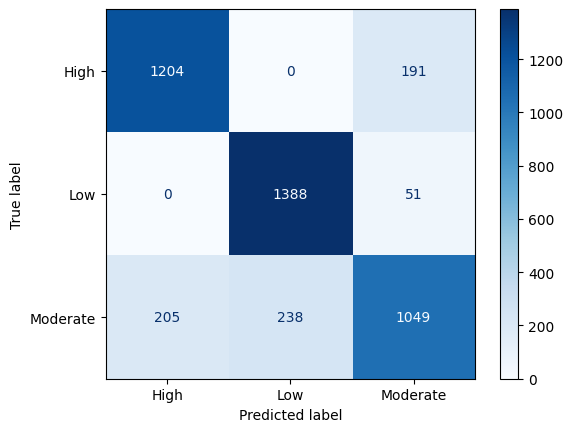

In [45]:
# Display EBM confusion MAtrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ebm,
    display_labels=label_encoder.classes_,
    cmap="Blues"
)

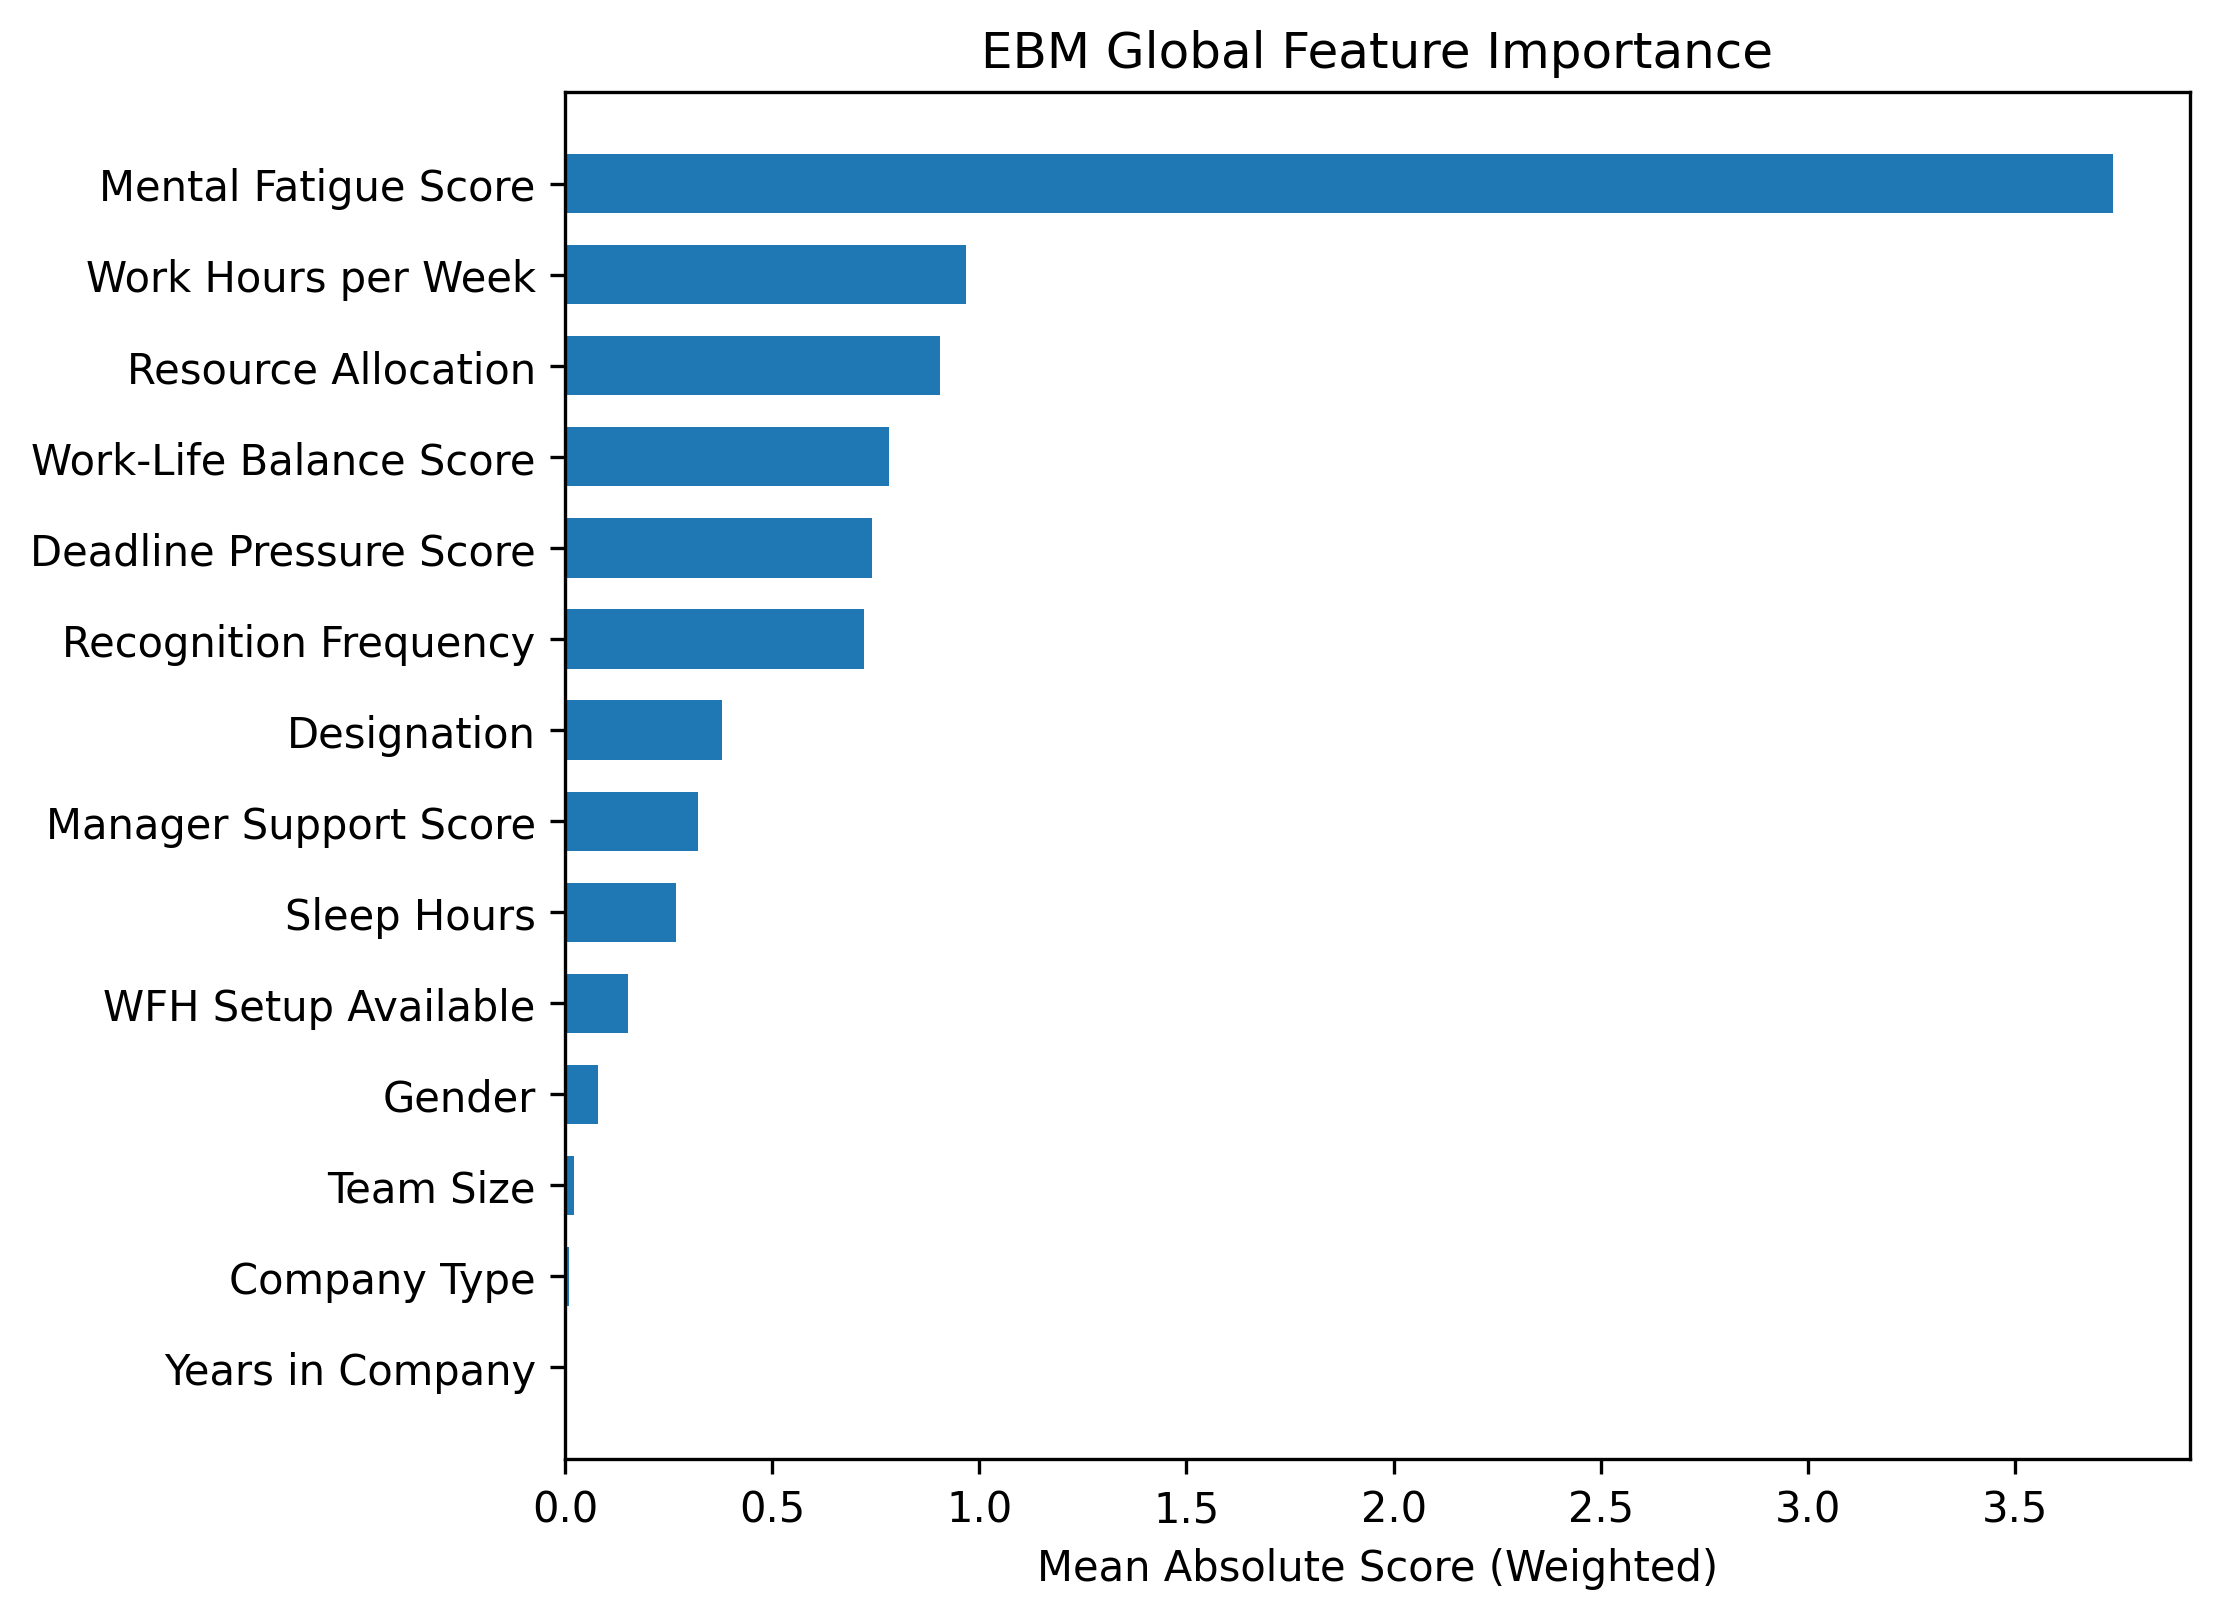

In [46]:
from interpret import show

# Generate global EBM explanation
ebm_global = ebm.explain_global()
ebm_data = ebm_global.data()

feature_names = np.array(ebm_data["names"])
feature_scores = np.array(ebm_data["scores"])

# Sort features by importance
order = np.argsort(feature_scores)

# Plot
plt.figure(figsize=(7.5, 5.5), dpi=300)

plt.barh(
    feature_names[order],
    feature_scores[order],
    height=0.65
)

plt.xlabel("Mean Absolute Score (Weighted)")
plt.title("EBM Global Feature Importance")

plt.tight_layout()
plt.show()

In [47]:
# 5-Fold Stratified Cross Validation for XGBoost for the tuned XGBoost model

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores_xgb = cross_val_score(
    best_xgb,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

cv_f1_xgb = cross_val_score(
    best_xgb,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

print("XGBoost Cross Validation Accuracy")
print(cv_scores_xgb)
print(f"Mean Accuracy: {cv_scores_xgb.mean():.4f}")
print(f"Mean Weighted F1: {cv_f1_xgb.mean():.4f}")

XGBoost Cross Validation Accuracy
[0.84624277 0.85231214 0.84913295 0.84190751 0.85346821]
Mean Accuracy: 0.8486
Mean Weighted F1: 0.8452


In [48]:
# Evaluate XGBoost Performance

print("Accuracy:",
      accuracy_score(y_test,
                     y_pred_xgb))

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=label_encoder.classes_
))

Accuracy: 0.8478964401294499
              precision    recall  f1-score   support

        High       0.86      0.87      0.86      1395
         Low       0.86      0.97      0.91      1439
    Moderate       0.83      0.70      0.76      1492

    accuracy                           0.85      4326
   macro avg       0.85      0.85      0.85      4326
weighted avg       0.85      0.85      0.84      4326



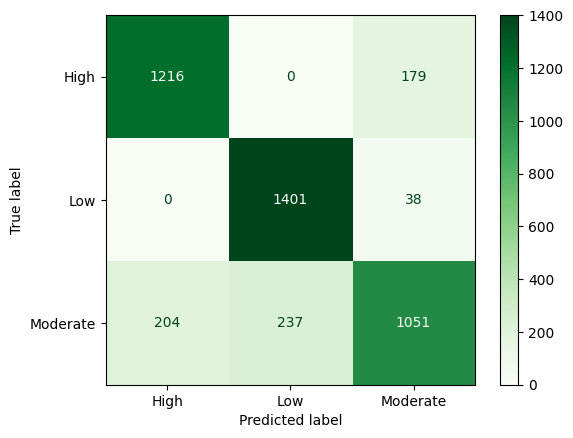

In [49]:
# Display XGBoost Confusion Matrix

ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred_xgb,

    display_labels=label_encoder.classes_,

    cmap="Greens"

)

In [50]:
# Add SHAP Explainability

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test)

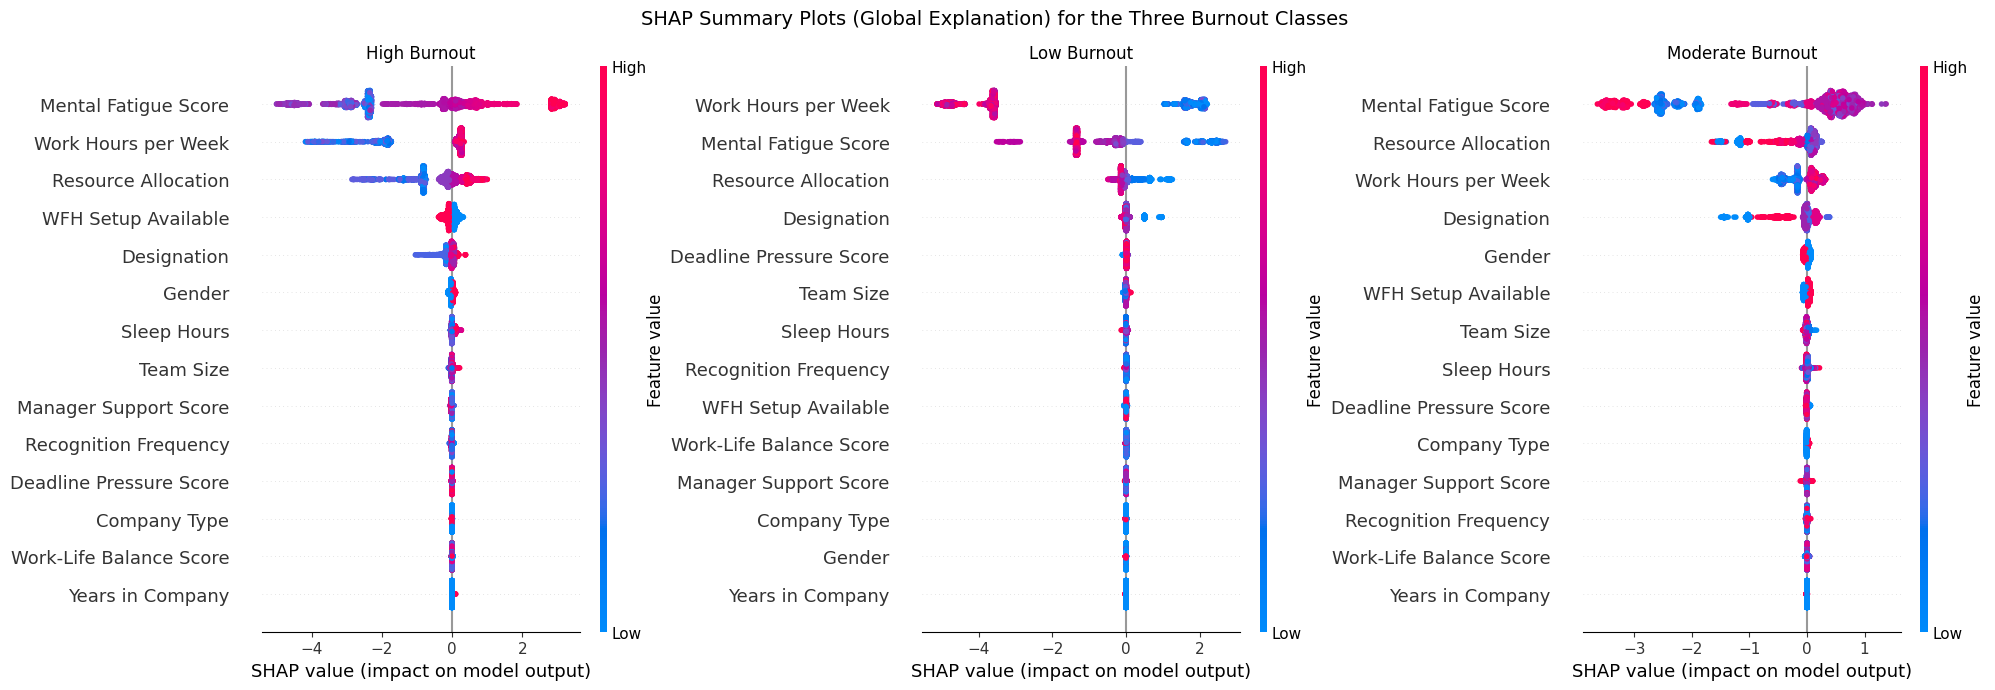

In [51]:
# SHAP Summary Plot (Global Explanation) 
# for the Three Burnout Classes 


class_names = label_encoder.classes_

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 7)
)

for class_index, class_name in enumerate(class_names):

    # SHAP values for the current burnout class
    class_shap_values = shap_values[:, :, class_index]

    # Create SHAP Explanation object
    class_explanation = shap.Explanation(
        values=class_shap_values,
        base_values=explainer.expected_value[class_index],
        data=X_test.values,
        feature_names=X_test.columns
    )

    # Generate beeswarm summary plot
    shap.plots.beeswarm(
        class_explanation,
        max_display=14,
        plot_size=None,
        show=False,
        ax=axes[class_index]
    )

    axes[class_index].set_title(
        f"{class_name} Burnout",
        fontsize=12
    )

fig.suptitle(
    "SHAP Summary Plots (Global Explanation) for the Three Burnout Classes",
    fontsize=14
)

plt.tight_layout()
plt.show()

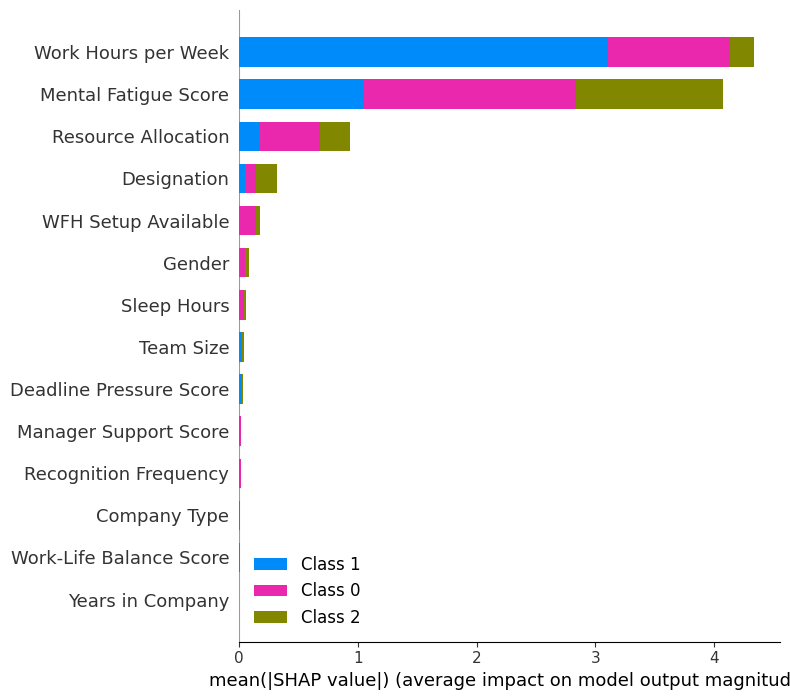

In [52]:
# Bar Plot

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.show()

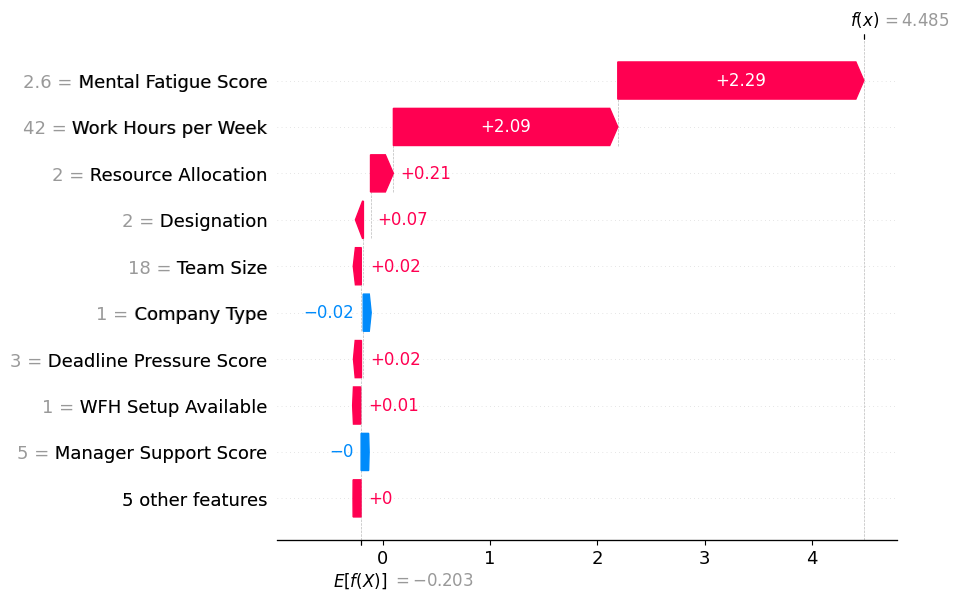

In [53]:
# SHAP Waterfall Plot
predicted_class = best_xgb.predict(X_test.iloc[[0]])[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, predicted_class],
        base_values=explainer.expected_value[predicted_class],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [54]:
print(type(shap_values))

print(np.array(shap_values).shape)

print(X_test.shape)

<class 'numpy.ndarray'>
(4326, 14, 3)
(4326, 14)


In [55]:
# Save the trained model

joblib.dump(best_xgb, "xgb_burnout_model.pkl")

['xgb_burnout_model.pkl']

In [56]:
# Save the Label Encoder

joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [57]:
# Save the Feature Names
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [58]:
# Save the SHAP Explainer
joblib.dump(explainer, "shap_explainer.pkl")

['shap_explainer.pkl']